In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
from math import factorial as fact

# **Problem Set 2: Distribuciones de Probabilidad de Variables Aleatorias Discretas**

**Asignatura:** Problemas de Astroestadística  
**Institución:** Pregrado de Astronomía - Universidad de Antioquia

### **Funciones de distribucion de probabilidad de interes**

In [3]:
# definicion de la funcion binomial
bin = lambda x, n, p: fact(n)/(fact(x)*fact(n - x)) * p**x * (1-p)**(n-x)


# **Punto 1**

**La tapa premiada**

Una marca de bebidas gaseosas está regalando un paquete de papitas si le sale una tapa premiada. Según la publicidad, una de cada cuatro tapas están premiadas. Sea $X$ una variable aleatoria que representa el número de tapas premiadas, si decide comprar 3 bebidas, responda:

**a)** Escriba la distribución de probabilidades de $X$ y realice una representación gráfica.

In [4]:
# la variable X sigue unba distrbucion binomial
bin_1 = lambda x : bin(x, 3, 1/4)


for i in range(4):
    print(f"Probabilidad de que X = {i}: ", bin_1(i))

Probabilidad de que X = 0:  0.421875
Probabilidad de que X = 1:  0.421875
Probabilidad de que X = 2:  0.140625
Probabilidad de que X = 3:  0.015625


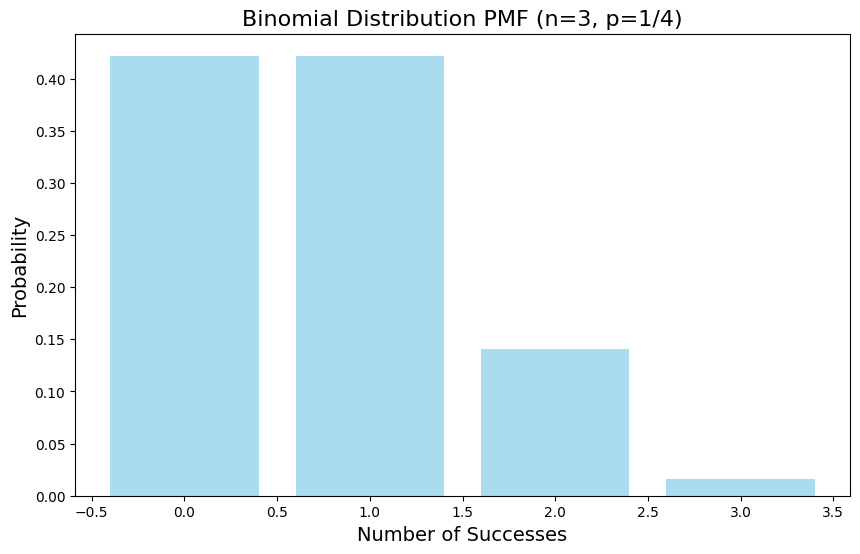

In [5]:
p = 1/4
q = 1 - p
n = 3 



plt.figure(figsize=(10, 6))
pmf = [stats.binom.pmf(k, n, p) for k in range(n + 1)]
plt.bar(range(n + 1), pmf, color='skyblue', alpha=0.7)
plt.title('Binomial Distribution PMF (n=3, p=1/4)', fontsize=16)
plt.xlabel('Number of Successes', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.show()



**b)** Escriba la función de distribución acumulada de $X$ y realice una representación gráfica.

Probabilidad acumulada de que X <= 0:  0.421875
Probabilidad acumulada de que X <= 1:  0.84375
Probabilidad acumulada de que X <= 2:  0.984375
Probabilidad acumulada de que X <= 3:  1.0


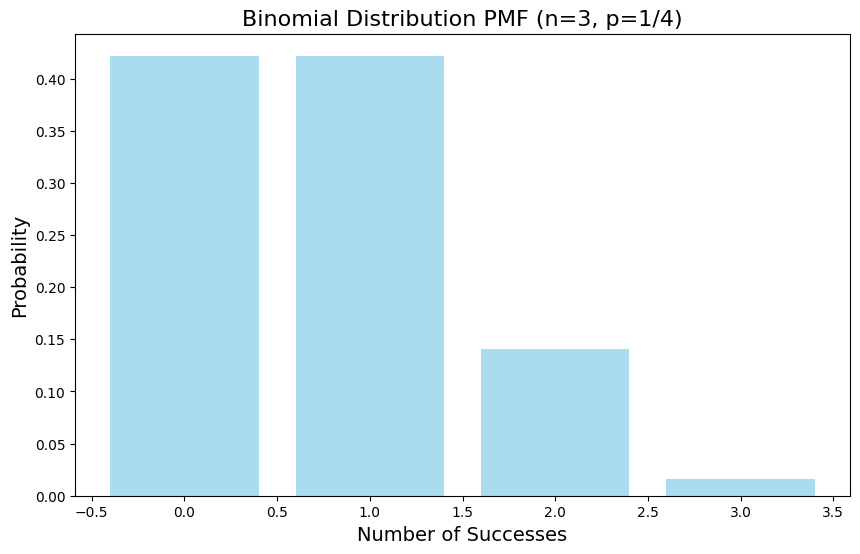

In [6]:
# se procede a escribir la funcion de probabilidad acumulada de esta binomial

bin_acum = lambda x: sum(bin_1(k) for k in range(x + 1))  #range recorre desde 0 hasta x, por eso se le suma 1

print("Probabilidad acumulada de que X <= 0: ", bin_acum(0))
print("Probabilidad acumulada de que X <= 1: ", bin_acum(1))
print("Probabilidad acumulada de que X <= 2: ", bin_acum(2))
print("Probabilidad acumulada de que X <= 3: ", bin_acum(3))


plt.figure(figsize=(10, 6))
pmf = [stats.binom.pmf(k, n, p) for k in range(n + 1)]
plt.bar(range(n + 1), pmf, color='skyblue', alpha=0.7)
plt.title('Binomial Distribution PMF (n=3, p=1/4)', fontsize=16)
plt.xlabel('Number of Successes', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.show()


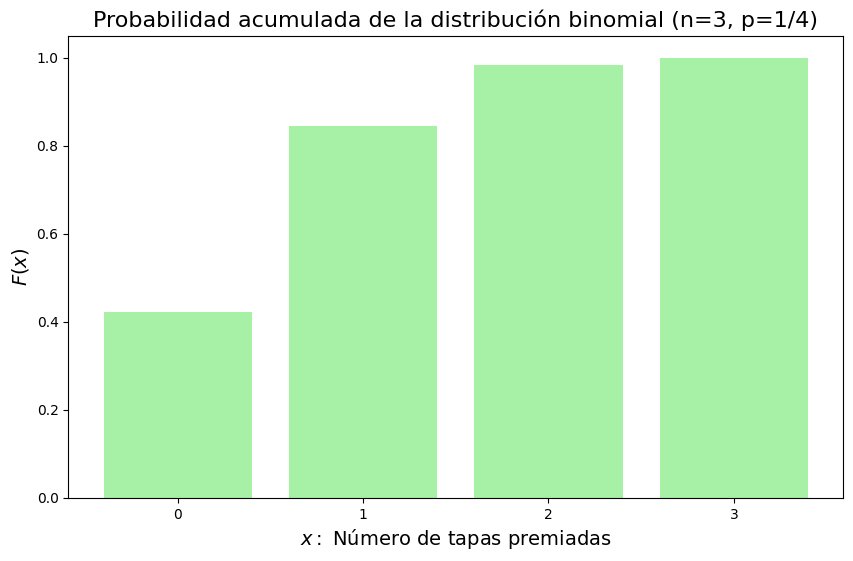

In [7]:
# grafica de la cumulada
F = [bin_acum(k) for k in range(n + 1)]

plt.figure(figsize=(10, 6))

plt.bar(range(n+1), F, color='lightgreen', alpha=0.8)
plt.title('Probabilidad acumulada de la distribución binomial (n=3, p=1/4)', fontsize=16)
plt.xlabel(r'$x :$ Número de tapas premiadas', fontsize=14)
plt.ylabel(r'$F(x)$', fontsize=14)
plt.xticks(range(n + 1))
plt.show()

**c)** ¿Cuál es la probabilidad de ganarse al menos un paquete de papitas? ¿Y exactamente uno? Compare.

In [8]:
print(f"La probabilidad de que se gane almenos un paquete es: \n- P(X >= 1) = 1 - F(1) ={1 - bin_acum(1)}")
print("--------------------------------")
print(f"La probabilidad de que se gane exactamente un paquete es: \n- P(X = 1) = {bin_1(1)}")



La probabilidad de que se gane almenos un paquete es: 
- P(X >= 1) = 1 - F(1) =0.15625
--------------------------------
La probabilidad de que se gane exactamente un paquete es: 
- P(X = 1) = 0.421875


**d)** Calcule el valor esperado y la varianza de $X$.

In [9]:
print("El valor esperado de la variable aleatoria X es: ", n*p)
print("La varianza de la variable aleatoria X es: ", n*p*q)
print("La desviación estándar de la variable aleatoria X es: ", (n*p*q)**0.5)

El valor esperado de la variable aleatoria X es:  0.75
La varianza de la variable aleatoria X es:  0.5625
La desviación estándar de la variable aleatoria X es:  0.75


**e)** Sea $Y$ la variable aleatoria que representa el número tapas sin premio menos el número tapas premiadas. Hallar la distribución de probabilidades de $Y$.

Los valores posibles de Y son:  [3, 1, -1, -3]


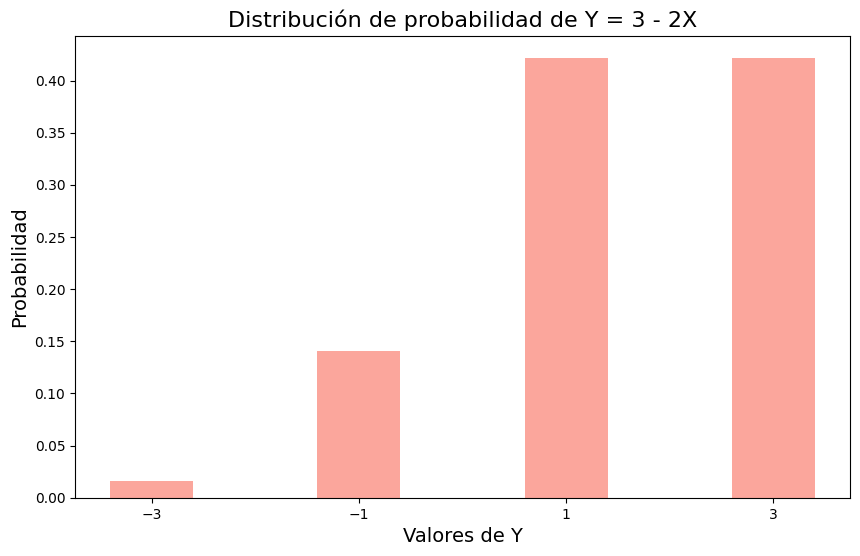

In [10]:
# como P(Y=y) = P(X=x) y Y = 3-2X
ys = [3 - 2*x for x in range(n + 1)]
print("Los valores posibles de Y son: ", ys)

plt.figure(figsize=(10, 6))
pmf_Y = [bin_1(x) for x in range(n + 1)]
plt.bar(ys, pmf_Y, color='salmon', alpha=0.7)
plt.title('Distribución de probabilidad de Y = 3 - 2X', fontsize=16)
plt.xlabel('Valores de Y', fontsize=14)
plt.ylabel('Probabilidad', fontsize=14)
plt.xticks(ys)  
plt.show()

**f)** Calcule el valor esperado y la varianza de $Y$.

In [11]:
print("El valor esperado de Y es: ", 3 - 2*n*p)
print("La varianza de Y es : ", 2**2 * n*p*q)
print("La desviación estándar de Y es: ", (2**2 * n*p*q)**0.5)

El valor esperado de Y es:  1.5
La varianza de Y es :  2.25
La desviación estándar de Y es:  1.5


**g)** Compare con los resultados obtenidos para $X$ y $Y$.

# **Punto 2**

**Moneda regular**

Suponga que realizamos el experimento de lanzar una moneda honrada un número $n$ de veces. Responda:

**a)** Describa (cuantitativamente) cómo hallar la probabilidad de que dos tercios de los lanzamientos sean sello.

In [ ]:
# como la moneda es justa, la probabilidad de que salga cara es 1/2. Sea X el número de caras en 10 lanzamientos. Entonces X sigue una distribución binomial con n=10 y p=1/2.
p_moneda = 1/2

# llamamos la funcion binomial definida anteriormente
bin_moneda_2_3 = lambda n: bin(int(2/3*n), n, p_moneda)

print("Para 5 lanzamientos, la probabilidad de que salga cara 2/3 de las veces es: ", bin_moneda_2_3(int(5)))
print("Para 20 lanzamientos, la probabilidad de que salga cara 2/3 de las veces es: ", bin_moneda_2_3(20))


TypeError: 'float' object cannot be interpreted as an integer

**b)** Al menos un tercio sea cara.

**c)** No más de un tercio sean sello.

**d)** (Numérico) Realice un código que lance una moneda honrada $n$ veces y guarde los resultados. Con ayuda de este código, considere un número $n$ lo suficientemente grande y compruebe los resultados analíticos encontrados en los literales anteriores.

# **Punto 3**

**Satélite de observación estelar**

Un satélite de observación estelar envía señales a la Tierra de forma aleatoria, con una tasa promedio de 3 señales por hora. Suponga que el envío de señales sigue un proceso de Poisson. Calcule la probabilidad de que:

**a)** El satélite envíe exactamente 5 señales en una hora determinada.

**b)** El satélite no envíe ninguna señal en un periodo de 2 horas.

**c)** El satélite envíe al menos 2 señales en un periodo de 30 minutos.

# **Punto 4**

**Detector de rayos cósmicos**

Un detector de rayos cósmicos registra el impacto de partículas provenientes del espacio. Suponga que la probabilidad de que el detector registre al menos una partícula en un intervalo de un milisegundo es $p=0.05$, y que los intervalos son independientes. Se requiere conocer el comportamiento del detector para planificar experimentos.

**a)** ¿Cuál es la probabilidad de que el detector registre la primera partícula exactamente en el décimo intervalo de un milisegundo?

**b)** ¿Cuál es el número esperado de intervalos que deben transcurrir hasta que se registre la primera partícula?

**c)** Calcule la probabilidad de que se necesiten más de 15 intervalos para registrar la primera partícula.

# **Punto 5**

**Exoplanetas por tránsito**

El telescopio espacial Kepler busca exoplanetas utilizando el método de tránsito. Suponga que la probabilidad de observar un tránsito en una curva de luz de una estrella es $p=0.015$. Si se escoge un conjunto curvas de forma aleatoria:

**a)** Se requiere encontrar la probabilidad de que se deban observar 100 curvas para identificar 2 tránsitos. ¿Qué tipo de variable aleatoria debe considerar? Escriba las funciones de distribución de probabilidad y acumulada.

**b)** Calcule la probabilidad mencionada.

**c)** ¿Cuál es la probabilidad de encontrar máximo 10 tránsitos de 150 curvas observadas?

**d)** Si se quiere encontrar 20 tránsitos ¿Cuántas curvas espera tener que analizar?

# **Punto 6**

**Estrellas variables**

Suponga que usted quiere estudiar las estrellas variables en un cúmulo estelar, en el que se han identificado 12 estrellas de este tipo, de las cuales 7 son Variables Cefeidas y 5 son de tipo RR Lyrae. Si comienza a estudiar cada estrella en orden aleatorio. Calcule la probabilidad de que de las primeras 6 estrellas estudiadas:

**a)** Cuatro sean Cefeidas

**b)** Máximo 4 sean RR Lyrae.

**c)** Determine la probabilidad de que el número de Cefeidas dentro de las primeras 6 estrellas observadas exceda su valor medio en más de una desviación estándar.

**d)** Suponga que ahora tiene un conjunto de 400 estrellas variables, de las cuáles 40 son Cefeidas. Si se escogen 15 de las 400 estrellas de forma aleatoria ¿cuál es la probabilidad de que a lo sumo 5 estrellas sean Cefeidas? Analice la posibilidad de utilizar una distribución diferente a la hipergeométrica.